# Pseudoscalar-mediated dark-matter bound-state production at the LHC

**What this notebook does.** It computes the LHC signal production cross section ($pp$, $\sqrt{s}=13$ TeV) for a dark-matter *bound state* — a "darkonium" — that is made through its mixing with a spin-0 **pseudoscalar mediator** $A$. The inputs are the mediator mass $m_A$, the dark-matter mass $m_\mathrm{DM}$, and a handful of dark-sector couplings; the output is the cross section $\sigma$ in femtobarns, summed over the two ways the LHC can make it (gluon fusion and quark–antiquark fusion) and corrected for higher-order QCD.

It is a Python port of an original Mathematica calculation (`PscalarXsec.nb`) and reproduces that calculation to better than $10^{-6}$ (Part VI). That number is how faithfully the *code* reproduces the original — not how precisely the rate is known: the absolute normalization carries a $\approx2.7\%$ offset and the calculation has no PDF or scale uncertainty attached (see the note in Part IV).

**Why this matters for SIDM.** The bound state $B$ here ($B_s$ in the sample names) *is* the signal of the CMS SIDM search: it decays $B_s\to$ two dark photons $Z_D$ (the code's ``Dp``) $\to$ di-lepton pairs — the $2\mu2e$ and $4\mu$ final states (samples like ``SIDM_BsTo2DpTo2Mu2e_MBs-100_MDp-0p25_ctau-0p02``). The $\sigma(pp\to B_s)$ computed here is the **production normalization** of those samples, which the analysis currently leaves as a placeholder $1$ fb for every point (``sidm/tools/utilities.get_xs``, ``configs/cross_sections.yaml``). Production factorizes from decay: $\sigma$ depends on the bound-state mass $M_{B_s}$ and the mediator/couplings, not on the dark-photon mass $M_{D_p}$ or lifetime $c\tau$ — so one $\sigma(M_{B_s})$ feeds the whole $(M_{D_p},c\tau)$ sub-grid of ``configs/signal_grid.yaml``.

**How to read it.** This is written for experimentalists who want the physical picture, not just a number. It runs as a story:

- **Part I — The model:** the pseudoscalar mediator and how it couples to dark matter and to quarks.
- **Part II — Darkonium:** what the dark-matter bound state is, and why it mixes with the mediator.
- **Part III — Production at the LHC:** the two production channels, and why gluon fusion wins.
- **Part IV — The signal cross section:** the headline results.
- **Part V — Scanning the parameters:** how each knob moves the rate.
- **Part VI — Validation:** the cross-check against the original calculation.

Each figure is introduced by the physics it shows.

## Setup

The calculation lives in two local modules next to this notebook: `pseudoscalar_xsec.py` (the cross-section engine) and `mstwpdf.py` (the parton-distribution interpolation), reading the PDF grid `mstw2008nnlo.00.dat`.

A note on the figures: the collider energy $\sqrt{s}=13$ TeV is shown only on the plots that actually depend on it (production rates and parton luminosities). Plots of model-internal quantities — the binding energy, the mixing, the parton distributions — carry no collider energy and are drawn without it.

In [1]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import mplhep as hep
import pandas as pd

# put the repo root on sys.path so `from sidm...` resolves to the working tree
sidm_path = os.getcwd().split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)
from sidm.tools import utilities
utilities.set_plot_style(dpi=110)        # mplhep CMS style + crisp inline figures
plt.rcParams["savefig.bbox"] = "tight"   # don't clip long axis labels in saved output

from mstwpdf import MSTWPDF
import pseudoscalar_xsec as px

pdf = MSTWPDF("mstw2008nnlo.00.dat")     # MSTW2008 NNLO central set
print(f"MSTW2008 NNLO grid loaded:  alpha_s(MZ) = {pdf.alphaSMZ:.5f},  "
      f"m_c = {pdf.mCharm} GeV,  m_b = {pdf.mBottom} GeV")

def log_minor(ax, axis="y"):
    # restore log minor ticks (matplotlib drops them on wide log ranges)
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
    a.set_minor_formatter(mticker.NullFormatter())

def leg(ax, **kw):
    # compact legend inside the axes: small title matched to the entry size, on a
    # near-opaque box, auto-placed by matplotlib to avoid the data
    kw.setdefault("loc", "best")
    kw.setdefault("fontsize", "x-small")
    kw.setdefault("title_fontsize", "x-small")
    kw.setdefault("framealpha", 0.9)
    return ax.legend(**kw)


def sqrt_s(ax, text=r"$\sqrt{s}=13$ TeV"):
    # collider-energy annotation (top-right margin); production-rate plots only
    hep.label.add_text(text, loc="over right", ax=ax)


MSTW2008 NNLO grid loaded:  alpha_s(MZ) = 0.11707,  m_c = 1.4 GeV,  m_b = 4.75 GeV


# Part I — The model

We use a **dark-matter simplified model**: the minimal recipe of a dark-matter particle plus one new particle (a "mediator") that connects the dark sector to the Standard Model. Here the mediator $A$ is a **pseudoscalar** — a spin-0, CP-odd state — exchanged between the two sectors. This is the standard spin-0 pseudoscalar benchmark of the ATLAS/CMS Dark Matter Forum [1].

The mediator couples to a dark-matter fermion $\chi$ and to Standard-Model quarks. The quark coupling is taken proportional to the quark mass, so the **heavy quarks — top and bottom — dominate everything**:

$$
\mathcal{L}_A = i\,g_\chi\, A\,\bar\chi\gamma_5\chi
\;+\; i\,A\sum_q g_q\,\frac{m_q}{v}\,\bar q\,\gamma_5 q ,
\qquad v = 246~\mathrm{GeV}.
$$

The whole calculation is controlled by six numbers ("handles" we scan in Part V):

| symbol | code | what it is |
|---|---|---|
| $m_A$ | `mA` | mediator mass [GeV] |
| $m_\mathrm{DM}$ | `mDM` | dark-matter mass [GeV] |
| $\alpha_D$ | `alphaD` | dark-sector coupling strength — this is what binds two DM particles together (Part II) |
| $y_\chi$ | `ychi` | how strongly the mediator couples to dark matter |
| $y_q$ | `yq` | overall strength of the mediator–quark couplings |
| $\tan\beta$ | `tanb` | balance between the up-type and down-type quark couplings |

The physical mediator–quark coupling is $g_q^A = y_q\,(m_q/v)$, with the up/down balance set by $\tan\beta$: down-type quarks scale as $y_q\tan\beta$ and up-type as $y_q/\tan\beta$. At $y_q=\tan\beta=1$ this is just $m_q/v$ — the universal-coupling case of Ref. [1]. Because the mediator can decay to the heavy quarks ($A\to b\bar b,\ t\bar t$), it has a total width $\Gamma_A$ that grows sharply once the $t\bar t$ channel opens above $m_A\approx2m_t$. This width sets how broad the production resonance is — it comes back in Part II.

# Part II — Darkonium and its mixing with the mediator

## The bound state

The dark sector has its own attractive interaction, with strength set by $\alpha_D$. Just as an electron and a positron can bind into positronium, two dark-matter particles can bind into a dark "atom" — a **bound state $B$, or "darkonium."** Its mass sits a little below $2m_\mathrm{DM}$ (by the binding energy), and it is very narrow:

$$
m_B = m_\mathrm{DM}\Big(2 - \tfrac14\alpha_D^2\Big),\qquad
E_\mathrm{bind} = \tfrac14\,\alpha_D^2\,m_\mathrm{DM},\qquad
\Gamma_\mathrm{BS} = \tfrac14\,\alpha_D^5\,(2 m_\mathrm{DM}).
$$

The binding energy grows like $\alpha_D^2$ and the width like $\alpha_D^5$ — the steep powers (plotted below) are why the bound state stays narrow and sits just under $2m_\mathrm{DM}$.

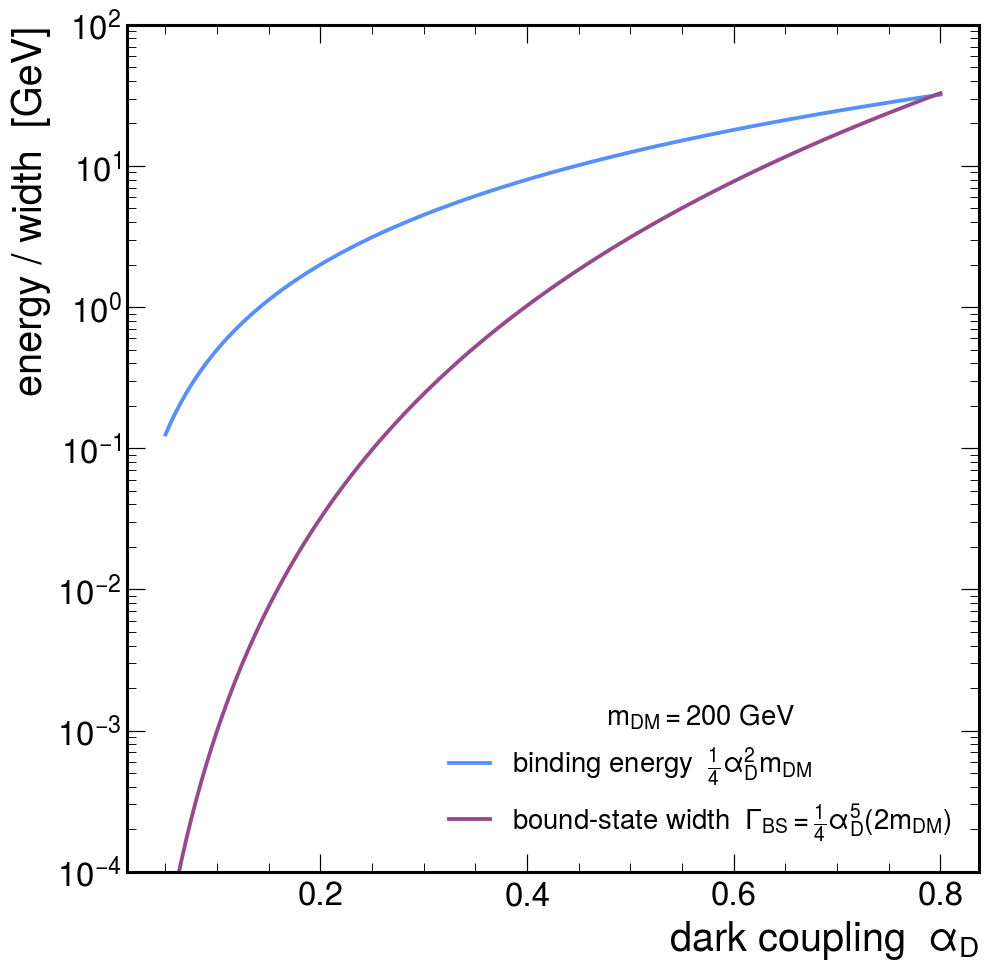

In [2]:
alphaD = np.linspace(0.05, 0.8, 300)
Eb = px.binding_energy(200.0, alphaD)
Gb = px.gamma_BS(200.0, alphaD)

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(alphaD, Eb, "C0-", lw=2.5, label=r"binding energy  $\frac{1}{4}\alpha_D^2 m_\mathrm{DM}$")
ax.plot(alphaD, Gb, "C3-", lw=2.5, label=r"bound-state width  $\Gamma_\mathrm{BS}=\frac{1}{4}\alpha_D^5(2m_\mathrm{DM})$")
ax.set_yscale("log"); log_minor(ax)
ax.set_xlabel(r"dark coupling  $\alpha_D$")
ax.set_ylabel(r"energy / width  [GeV]")
ax.set_ylim(1e-4, 1e2)
leg(ax, title=r"$m_\mathrm{DM}=200$ GeV")
plt.show()

## Why it mixes, and what mixing does

The darkonium ground state is CP-odd — it carries the **same quantum numbers as the pseudoscalar mediator $A$**. In quantum mechanics, two states with the same quantum numbers mix, like two coupled pendulums. The physical states come from diagonalizing a $2\times2$ matrix: the diagonal entries are (mass$^2 - i\times$mass$\times$width) for the mediator and for the bound state, and the off-diagonal entry $f^2$ is how strongly they talk to each other:

$$
M = \begin{pmatrix} m_A^2 - i\,m_A\Gamma_A & -f^2 \\[2pt] -f^2 & (2m_\mathrm{DM})^2 - i\,(2m_\mathrm{DM})\Gamma_\mathrm{BS}\end{pmatrix},
\qquad f^2 = \frac{\alpha_D^3\, m_\mathrm{DM}^2}{8\pi}.
$$

The off-diagonal $f^2$ is set by how often the two dark-matter constituents sit on top of each other (the wavefunction at the origin) — they can only turn into an $A$ where they overlap. The width entries are imaginary because an unstable state has a complex energy; for each eigenvalue the real part is a physical mass$^2$ and the imaginary part is mass$\times$width.

In our regime the mediator is **broad** ($\Gamma_A$ of tens of GeV) and the off-diagonal coupling is small, so the mixing is gentle: the bound state stays narrow and is produced through the small piece of mediator mixed into it. The one thing to take away is a **resonance** — production is strongly enhanced when the bound state and the mediator are nearly degenerate ($2m_\mathrm{DM}\approx m_A$), and the *width* of that resonance is set by the mediator width $\Gamma_A$. A broader mediator gives a lower, wider peak.

The figure shows this resonance shape for three mediator widths (set by $y_q$). One twist worth flagging: turning $y_q$ up raises production but also broadens the mediator, and on the peak the broadening wins — so more quark coupling can actually *lower* the peak rate. We come back to this in Part V.

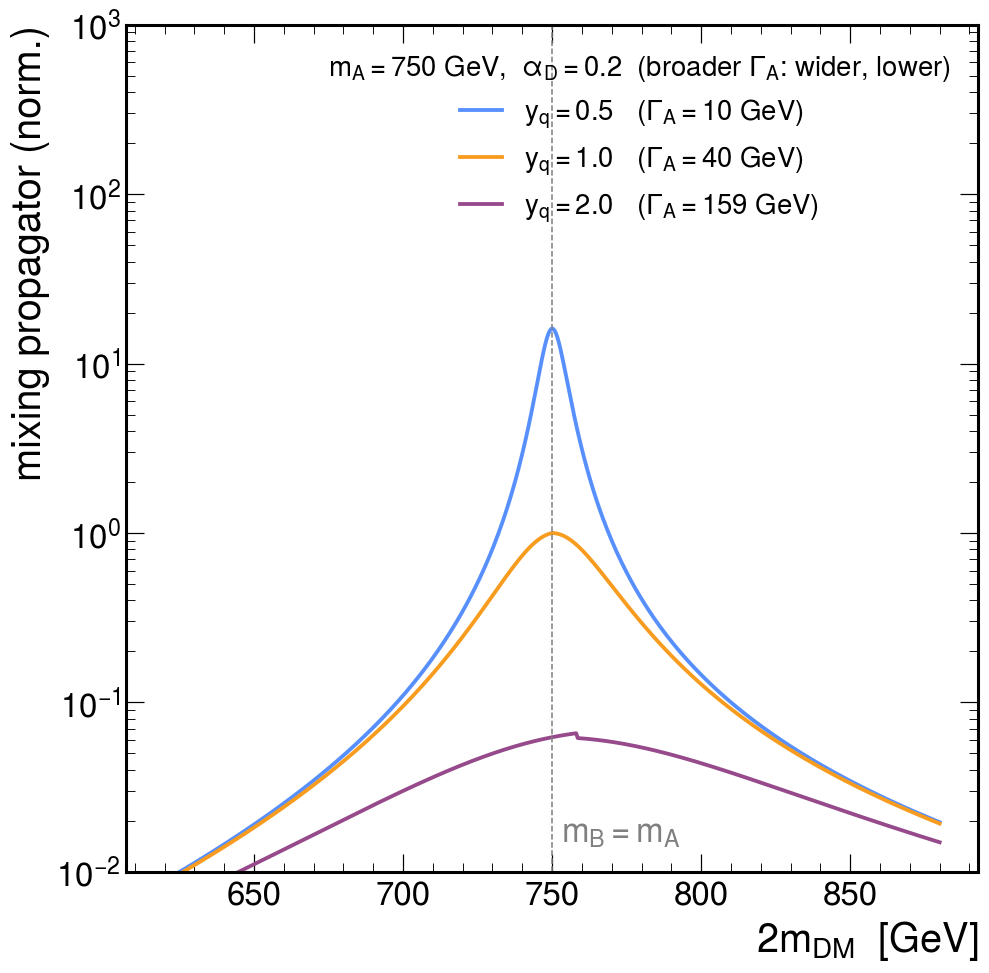

In [3]:
twomDM = np.linspace(620, 880, 500)

def propagator(t, yq):
    m = px.mixing(t / 2.0, 750, 1, 0.2, yq)
    D = (m["mB2"] - m["mM2"]) ** 2 + (m["Gamma_M"] * m["mass_M"] - m["Gamma_B"] * m["mass_B"]) ** 2
    return m["mB2"] ** 3 / D

configs = [(0.5, "C0"), (1.0, "C1"), (2.0, "C3")]
Ps = {yq: np.array([propagator(t, yq) for t in twomDM]) for yq, _ in configs}
ref = Ps[1.0].max()                       # normalize to the y_q = 1 peak

fig, ax = plt.subplots(figsize=(10, 10))
for yq, c in configs:
    GA = px.gamma_A(750, 1, yq)
    ax.plot(twomDM, Ps[yq] / ref, c + "-", lw=2.5,
            label=fr"$y_q={yq}$   ($\Gamma_A={GA:.0f}$ GeV)")
ax.axvline(750, color="grey", ls="--", lw=1)
ax.text(753, 1.5e-2, r"$m_B=m_A$", color="grey", fontsize="small")
ax.set_yscale("log"); log_minor(ax)
ax.set_ylim(1e-2, 1e3)
ax.set_xlabel(r"$2m_\mathrm{DM}$  [GeV]")
ax.set_ylabel(r"mixing propagator (norm.)")
leg(ax, title=r"$m_A=750$ GeV,  $\alpha_D=0.2$  (broader $\Gamma_A$: wider, lower)")
plt.show()

The cross sections carry an overall factor $\zeta(3)=\sum_n 1/n^3 \approx 1.202$. This sums over the whole tower of radial excitations of the bound state (the $nS$ states), not just the ground state [4, 5].

# Part III — Production at the LHC

## Two ways to make it, and why gluon fusion wins

To make the bound state we make a mediator from the colliding protons' partons and read off the bound-state piece mixed into it. Two parton-level channels contribute:

1. **Gluon fusion**, $gg\to A\to B$. A pseudoscalar does not couple to gluons directly, so the gluons reach it through a loop of heavy quarks (mostly the top). This is the same mechanism as Standard-Model Higgs production.
2. **Quark–antiquark fusion**, $q\bar q\to A\to B$. The coupling grows with quark mass, so this is dominated by $b\bar b$ (the top has no parton distribution to draw on).

Which channel wins is decided by the **parton luminosities** — how many gluon pairs versus quark pairs the protons actually deliver at the mass of interest. The plot below shows the luminosity factor multiplying each partonic cross section at $\sqrt{s}=13$ TeV, computed from the MSTW2008 parton distributions [6]. The gluon–gluon luminosity sits far above the quark channels across the whole mass range; together with the large top loop, that is why **gluon fusion dominates**.

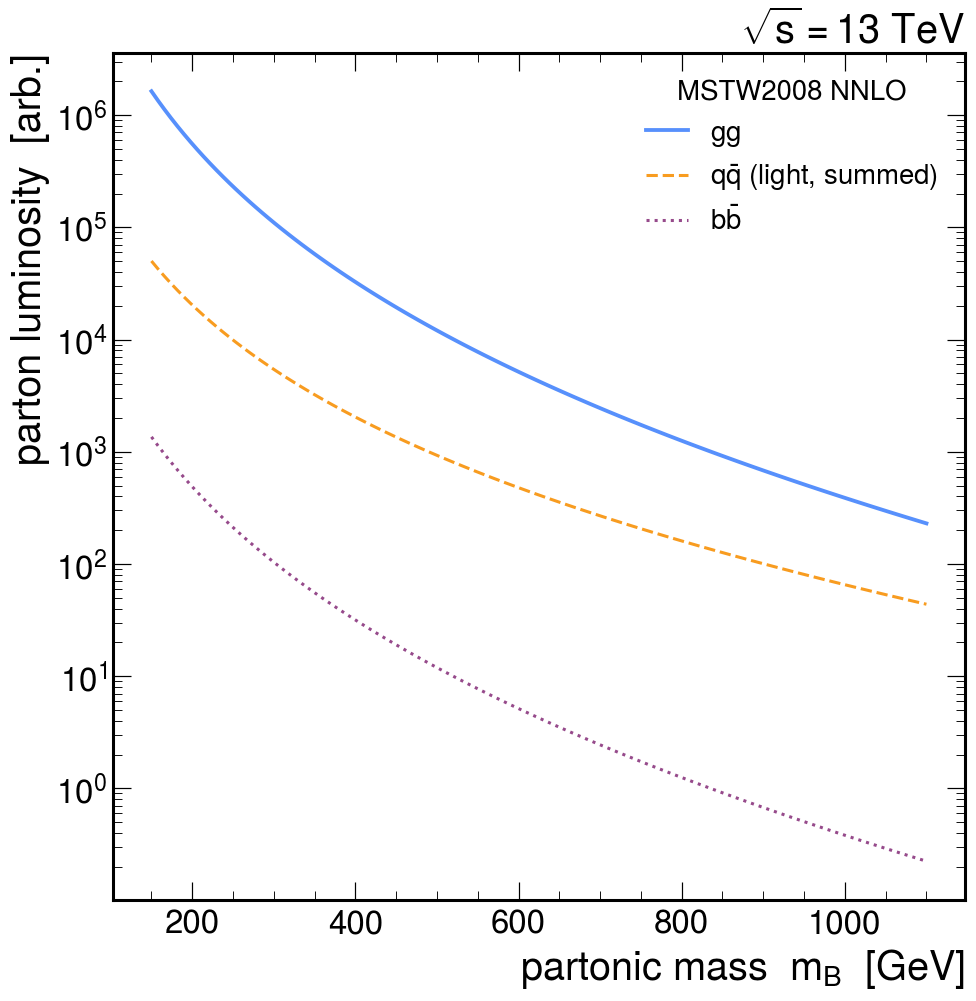

In [4]:
mB = np.linspace(150, 1100, 120)
lum = {ch: np.array([px.parton_lumi(pdf, m, ch) for m in mB])
       for ch in ["gg", "qqbar", "bb"]}

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(mB, lum["gg"],    "C0-",  lw=2.5, label=r"$gg$")
ax.plot(mB, lum["qqbar"], "C1--", lw=2,   label=r"$q\bar q$ (light, summed)")
ax.plot(mB, lum["bb"],    "C3:",  lw=2,   label=r"$b\bar b$")
ax.set_yscale("log"); log_minor(ax)
ax.set_xlabel(r"partonic mass  $m_B$  [GeV]")
ax.set_ylabel(r"parton luminosity  [arb.]")
leg(ax, title=r"MSTW2008 NNLO")
sqrt_s(ax)
plt.show()

# Part IV — The signal cross section

## A worked example

For one benchmark point, here is the full chain: the mediator width, the two physical (mixed) masses, the bound-state width, and the two production cross sections that add up to the total. Each parton-level rate is computed at leading order and then scaled by a QCD **K-factor** (a multiplicative factor of $\approx2$–$3$ that captures the higher-order corrections, which are large for gluon-fusion production; from the higher-order gluon-fusion [2] and bottom-fusion [3] calculations). Gluon fusion dominates by orders of magnitude, as expected. (This benchmark point sits *off* the resonance — $m_B=360$ GeV with $m_A=750$ GeV — so the rate is modest, $\approx0.9$ fb; on the resonance the same couplings give a rate roughly $90\times$ larger, as the next plots show.)

> **A note on the absolute normalization.** The cross sections here are absolute rates in fb, but two caveats apply to their *overall scale*. (1) Following the original calculation, the GeV$^{-2}\to$ fb unit conversion uses $\hbar c\approx2\times10^{-14}$ cm GeV, which is $\approx2.7\%$ above the exact value — so every absolute rate is high by that factor (divide by $1.027$ to correct it). (2) The calculation uses a single PDF set with fixed K-factors, so it has **no PDF or scale uncertainty** attached; the scale uncertainty on gluon-fusion production alone would be $\mathcal{O}(10$–$20\%)$, much larger than the $2.7\%$ offset. Treat these as central-value estimates, not precision predictions.

In [5]:
bd = px.breakdown(pdf, mDM=180, mA=750, tanb=1, alphaD=0.2, yq=1, ychi=1)

print(f"Inputs:  m_DM = {bd['mDM']} GeV,  m_A = {bd['mA']} GeV,  "
      f"alpha_D = {bd['alphaD']},  y_chi = {bd['ychi']},  y_q = {bd['yq']},  tan(beta) = {bd['tanb']}")
print("-" * 64)
print(f"Mediator total width   Gamma_A   = {bd['Gamma_A']:8.3f} GeV")
print(f"Bound-state mass       m_B       = {bd['mass_boundstate']:8.2f} GeV")
print(f"Mediator-like mass     m_M       = {bd['mass_mediatorlike']:8.2f} GeV")
print(f"Bound-state width      Gamma_B   = {bd['Gamma_boundstate_like']:8.4g} GeV"
      f"   (Gamma_BS << Gamma_A: {bd['Gamma_boundstate_like'] < bd['Gamma_A']})")
print("-" * 64)
print(f"  gluon fusion   :  sigma = {bd['sigma_gg']:9.4g} fb   (LO x Kgg, Kgg = {bd['Kgg']:.3f})")
print(f"  qqbar fusion   :  sigma = {bd['sigma_qq']:9.4g} fb   (LO x Kqq, Kqq = {bd['Kqq']:.3f})")
print(f"  {'':14s}  {'-'*30}")
print(f"  TOTAL          :  sigma = {bd['sigma_total']:9.4g} fb")

Inputs:  m_DM = 180 GeV,  m_A = 750 GeV,  alpha_D = 0.2,  y_chi = 1,  y_q = 1,  tan(beta) = 1
----------------------------------------------------------------
Mediator total width   Gamma_A   =   39.685 GeV
Bound-state mass       m_B       =   360.00 GeV
Mediator-like mass     m_M       =   750.00 GeV
Bound-state width      Gamma_B   =   0.0288 GeV   (Gamma_BS << Gamma_A: True)
----------------------------------------------------------------
  gluon fusion   :  sigma =    0.8884 fb   (LO x Kgg, Kgg = 2.552)
  qqbar fusion   :  sigma =  0.003171 fb   (LO x Kqq, Kqq = 2.167)
                  ------------------------------
  TOTAL          :  sigma =    0.8916 fb


## Cross section vs. bound-state mass

The signal cross section as a function of the bound-state mass $m_B$, for several mediator masses $m_A$. Each curve **peaks where $m_B\approx m_A$** — there the bound state and the mediator are nearly degenerate and the mixing is resonant (Part II). The kink near $m_B\approx2m_t\approx350$ GeV is the top-quark threshold turning on in the production loop: above $m_B=2m_t$ the heavy-quark loop can produce a real $t\bar t$ pair and its form factor goes complex. (The mediator width plays no role here — $m_A$ is fixed along each curve, so $\Gamma_A$ is constant.)

For the SIDM grid, read $\sigma$ off the $m_B$ axis at the sample's bound-state mass $M_{B_s}$ on the relevant $m_A$ curve — that value is the production normalization that replaces the 1 fb placeholder. The grid masses generally sit off the $m_B=m_A$ resonance, which is why the curves are drawn across the full mass range.

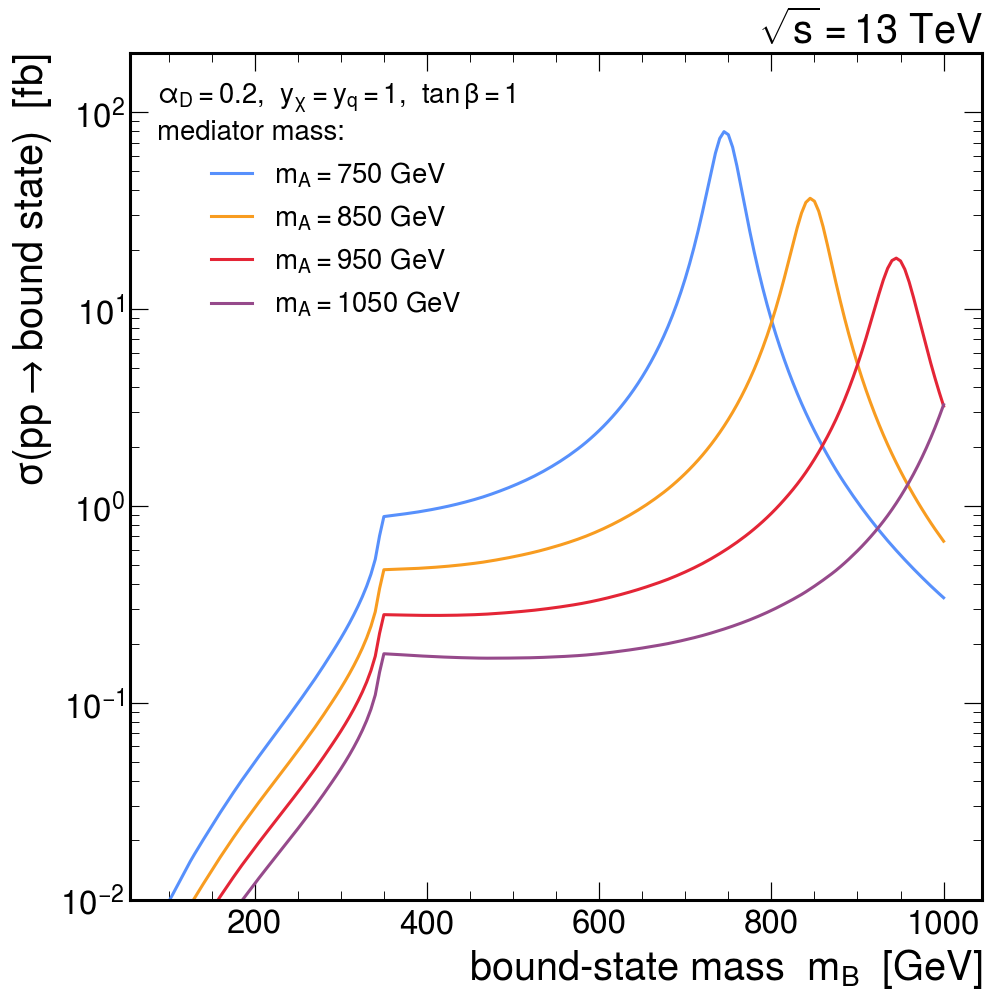

In [6]:
mB = np.arange(100, 1001, 5.0)
fig, ax = plt.subplots(figsize=(10, 10))
for mA in [750, 850, 950, 1050]:
    _, _, tot = px.scan_mB(pdf, mB, mA=mA, tanb=1, alphaD=0.2, yq=1, ychi=1)
    ax.plot(mB, tot, lw=2, label=fr"$m_A = {mA}$ GeV")
ax.set_yscale("log"); log_minor(ax)
ax.set_xlabel(r"bound-state mass  $m_B$  [GeV]")
ax.set_ylabel(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
ax.set_ylim(1e-2, 2e2)
leg(ax, title="$\\alpha_D=0.2$,  $y_\\chi=y_q=1$,  $\\tan\\beta=1$\nmediator mass:",
          framealpha=0.9)
sqrt_s(ax)
plt.show()

## Gluon fusion vs. quark–antiquark

Splitting the total into its two channels at a fixed mediator mass: gluon fusion dominates across the whole range by 2–3 orders of magnitude, driven by the large gluon luminosity and the top-quark loop.

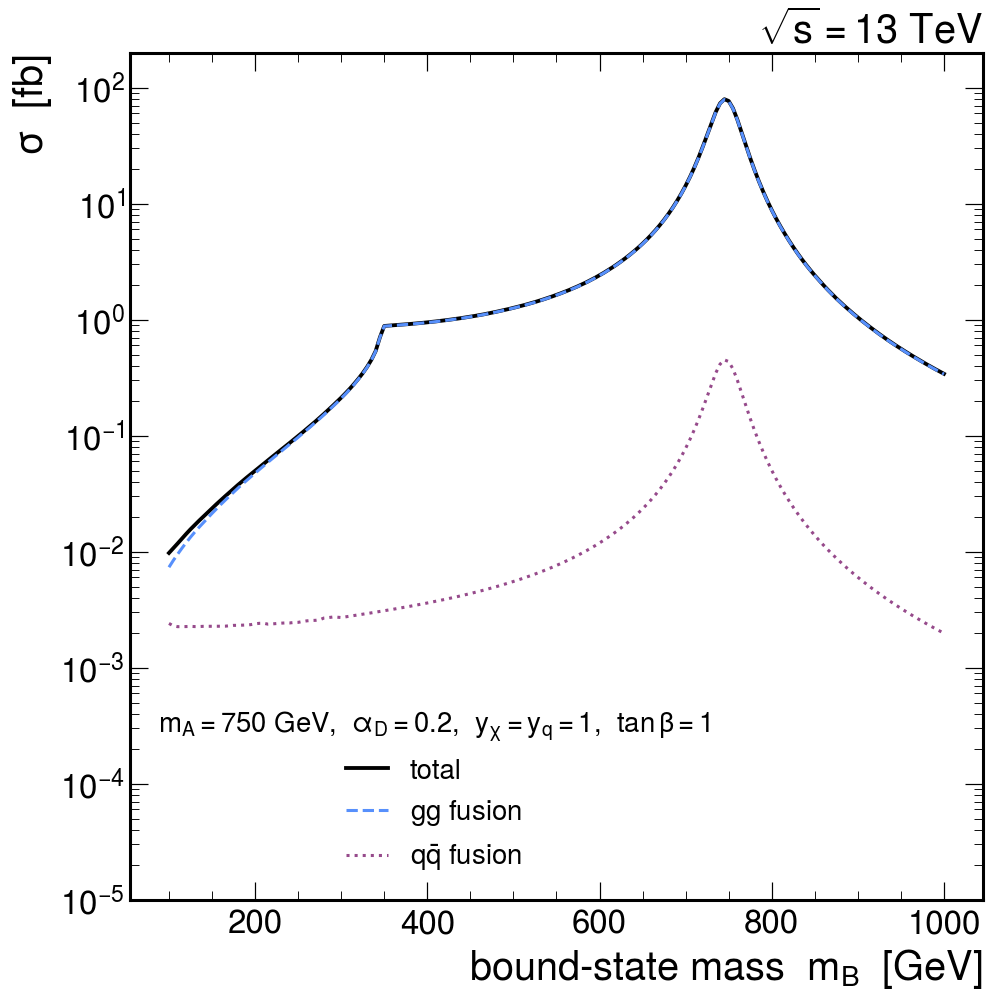

In [7]:
mB = np.arange(100, 1001, 5.0)
gg, qq, tot = px.scan_mB(pdf, mB, mA=750, tanb=1, alphaD=0.2, yq=1, ychi=1)
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(mB, tot, "k-",  lw=2.5, label="total")
ax.plot(mB, gg,  "C0--", lw=2,  label=r"$gg$ fusion")
ax.plot(mB, qq,  "C3:",  lw=2,  label=r"$q\bar q$ fusion")
ax.set_yscale("log"); log_minor(ax)
ax.set_xlabel(r"bound-state mass  $m_B$  [GeV]")
ax.set_ylabel(r"$\sigma$  [fb]")
ax.set_ylim(1e-5, 2e2)
leg(ax, title=r"$m_A=750$ GeV,  $\alpha_D=0.2$,  $y_\chi=y_q=1$,  $\tan\beta=1$")
sqrt_s(ax)
plt.show()

## The resonance line shape

Zooming in around $m_B=m_A$ shows the resonance directly. It peaks at $m_B\simeq m_A$, and its **width is set by the mediator width $\Gamma_A$** — the narrow bound state inherits the mediator's line shape through the mixing. Increasing $\alpha_D$ raises the peak (production grows as $\alpha_D^3$) while the width stays controlled by $\Gamma_A$.

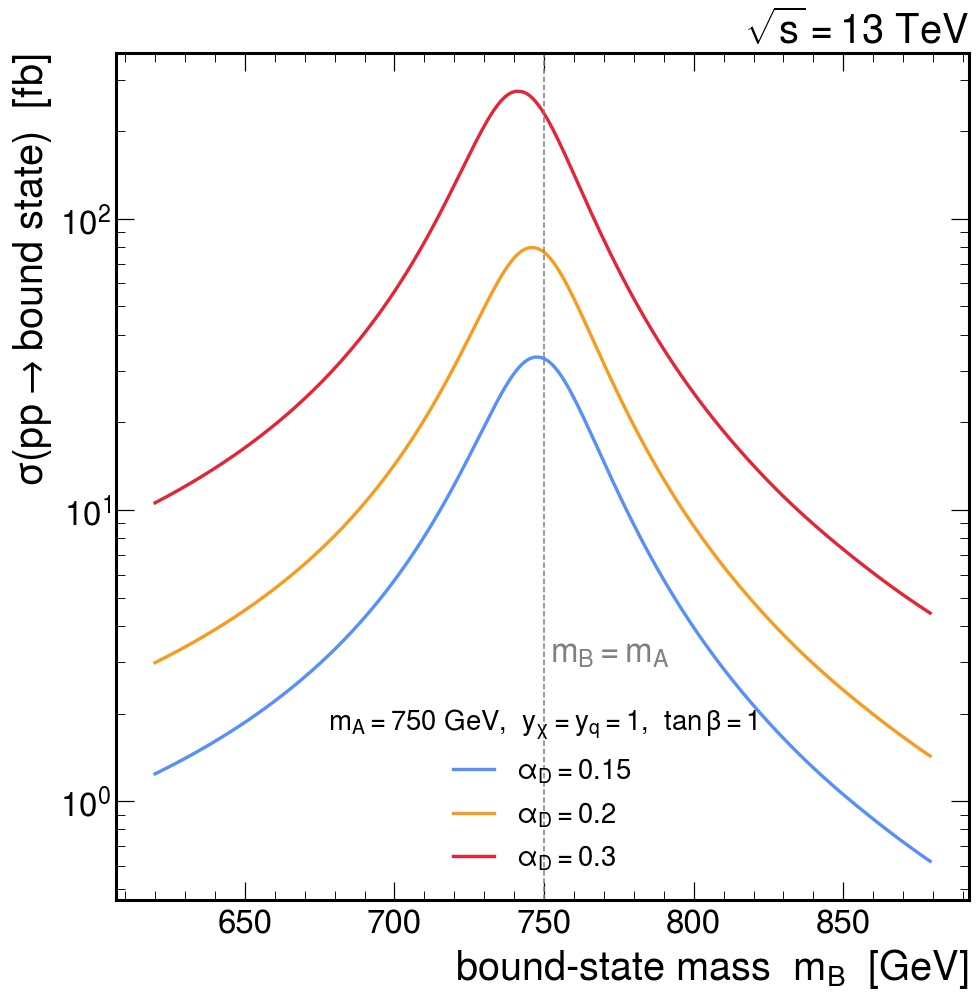

In [8]:
mB = np.arange(620, 880, 1.0)
fig, ax = plt.subplots(figsize=(10, 10))
for aD in [0.15, 0.2, 0.3]:
    _, _, tot = px.scan_mB(pdf, mB, mA=750, tanb=1, alphaD=aD, yq=1, ychi=1)
    ax.plot(mB, tot, lw=2.2, label=fr"$\alpha_D = {aD}$")
ax.axvline(750, color="grey", ls="--", lw=1)
ax.text(752, 3, r"$m_B=m_A$", color="grey", fontsize="small")
ax.set_yscale("log"); log_minor(ax)
ax.set_xlabel(r"bound-state mass  $m_B$  [GeV]")
ax.set_ylabel(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
leg(ax, title=r"$m_A=750$ GeV,  $y_\chi=y_q=1$,  $\tan\beta=1$")
sqrt_s(ax)
plt.show()

## The full $(m_B,\,m_A)$ plane

The cross section over the whole plane of bound-state mass and mediator mass. The bright diagonal ridge is the resonance condition $m_B=m_A$; off the ridge toward smaller $m_B$ the rate falls steeply, while above the ridge it flattens into a plateau (see the note below).

That plateau above the ridge ($m_B>m_A$) is a book-keeping effect, not new physics: the code labels the two mixed states by their mass, so above the ridge the one it calls the "bound state" effectively follows the mediator mass. The plateau reflects that labeling rather than genuine production of a very heavy $2m_\mathrm{DM}$ state; the curves stay smooth.

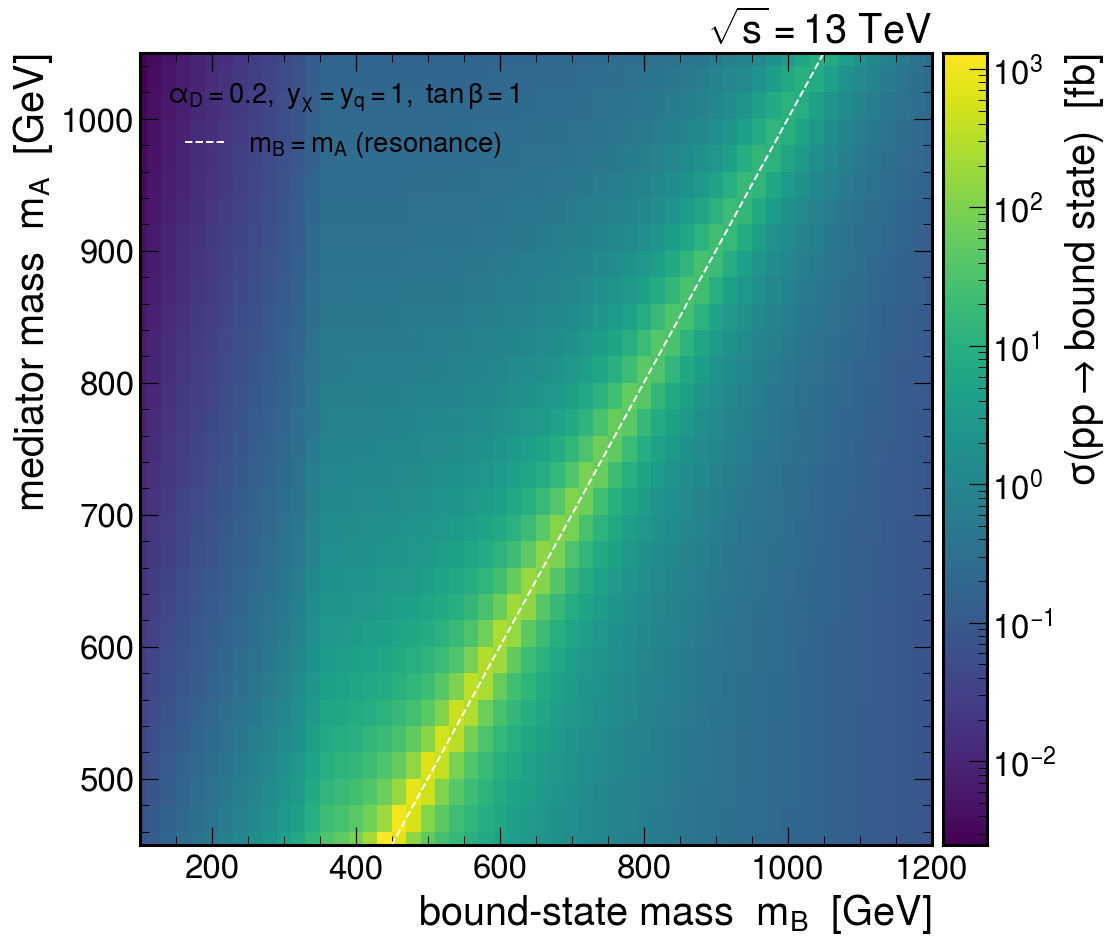

In [9]:
mB = np.arange(100, 1201, 20.0)
mA = np.arange(450, 1051, 20.0)
Z = px.scan_grid(pdf, mB, mA, tanb=1, alphaD=0.2, yq=1, ychi=1)

fig, ax = plt.subplots(figsize=(10, 10))
pcm = ax.pcolormesh(mB, mA, Z, shading="auto", cmap="viridis",
                    norm=LogNorm(vmin=max(Z.min(), 1e-3), vmax=Z.max()))
ax.plot(mB, mB, "w--", lw=1.3, label=r"$m_B=m_A$ (resonance)")
ax.set_xlim(mB.min(), mB.max()); ax.set_ylim(mA.min(), mA.max())
ax.set_xlabel(r"bound-state mass  $m_B$  [GeV]")
ax.set_ylabel(r"mediator mass  $m_A$  [GeV]")
ax.legend(loc="upper left", framealpha=0.9, fontsize="x-small", title_fontsize="x-small",
          title=r"$\alpha_D=0.2,\ y_\chi=y_q=1,\ \tan\beta=1$")
cax = hep.utils.make_square_add_cbar(ax, pad=0.1)
cb = fig.colorbar(pcm, cax=cax)
cb.set_label(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
sqrt_s(ax)
plt.show()

# Part V — Scanning the parameters

## The benchmark and its assumptions

The plots so far used the benchmark $\alpha_D=0.2$, $y_\chi=y_q=1$, $\tan\beta=1$. Two assumptions go into the formula:

- **The bound state is much narrower than the mediator** ($\Gamma_\mathrm{BS}\ll\Gamma_A$), so the resonance is controlled by the mediator and the result barely depends on the precise bound-state width. This holds comfortably up to $\alpha_D\approx0.3$; by $\alpha_D=0.5$ it is only marginal (the bound-state width is no longer negligible and the peak can shift by up to $\sim40\%$), so the top of the $\alpha_D$ scan below should be read as indicative.
- **$\tan\beta=1$**, which makes the up- and down-type quark couplings equal. We also take $m_A>2m_\mathrm{DM}$.

The remaining figures vary one handle at a time.

### $\alpha_D$ — the dark coupling

$\alpha_D$ enters in three places: it sets the production strength ($\sigma\propto\alpha_D^3$, from the overlap of the two constituents), the binding energy, and the bound-state width. Turning it up lifts the whole curve steeply and slightly shifts the peak.

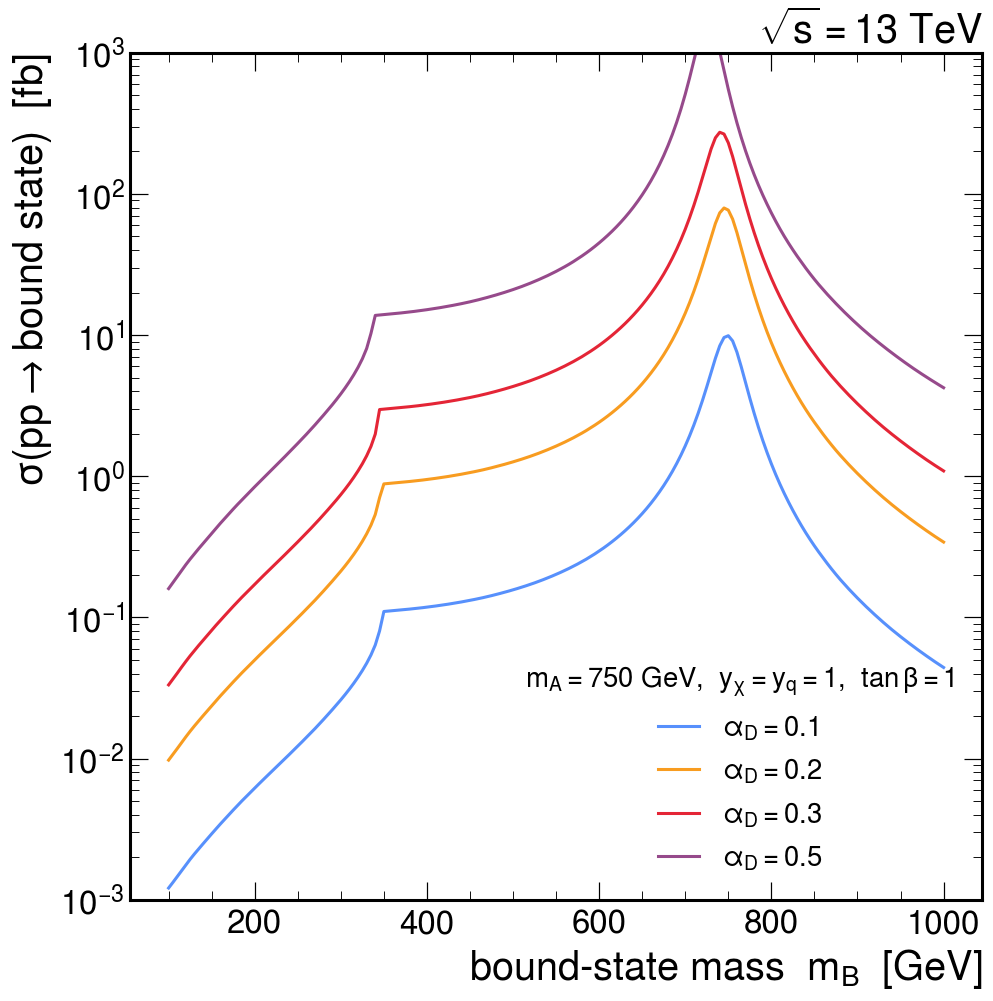

In [10]:
mB = np.arange(100, 1001, 5.0)
fig, ax = plt.subplots(figsize=(10, 10))
for aD in [0.1, 0.2, 0.3, 0.5]:
    _, _, tot = px.scan_mB(pdf, mB, mA=750, tanb=1, alphaD=aD, yq=1, ychi=1)
    ax.plot(mB, tot, lw=2, label=fr"$\alpha_D = {aD}$")
ax.set_yscale("log"); log_minor(ax)
ax.set_xlabel(r"bound-state mass  $m_B$  [GeV]")
ax.set_ylabel(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
ax.set_ylim(1e-3, 1e3)
leg(ax, title=r"$m_A=750$ GeV,  $y_\chi=y_q=1$,  $\tan\beta=1$")
sqrt_s(ax)
plt.show()

### $y_\chi$ — the mediator–dark-matter coupling

$y_\chi$ only enters the production vertex, so the rate scales cleanly as $\sigma\propto y_\chi^2$ — a straight line of slope 2 on a log–log plot, the same everywhere regardless of where you sit relative to the resonance.

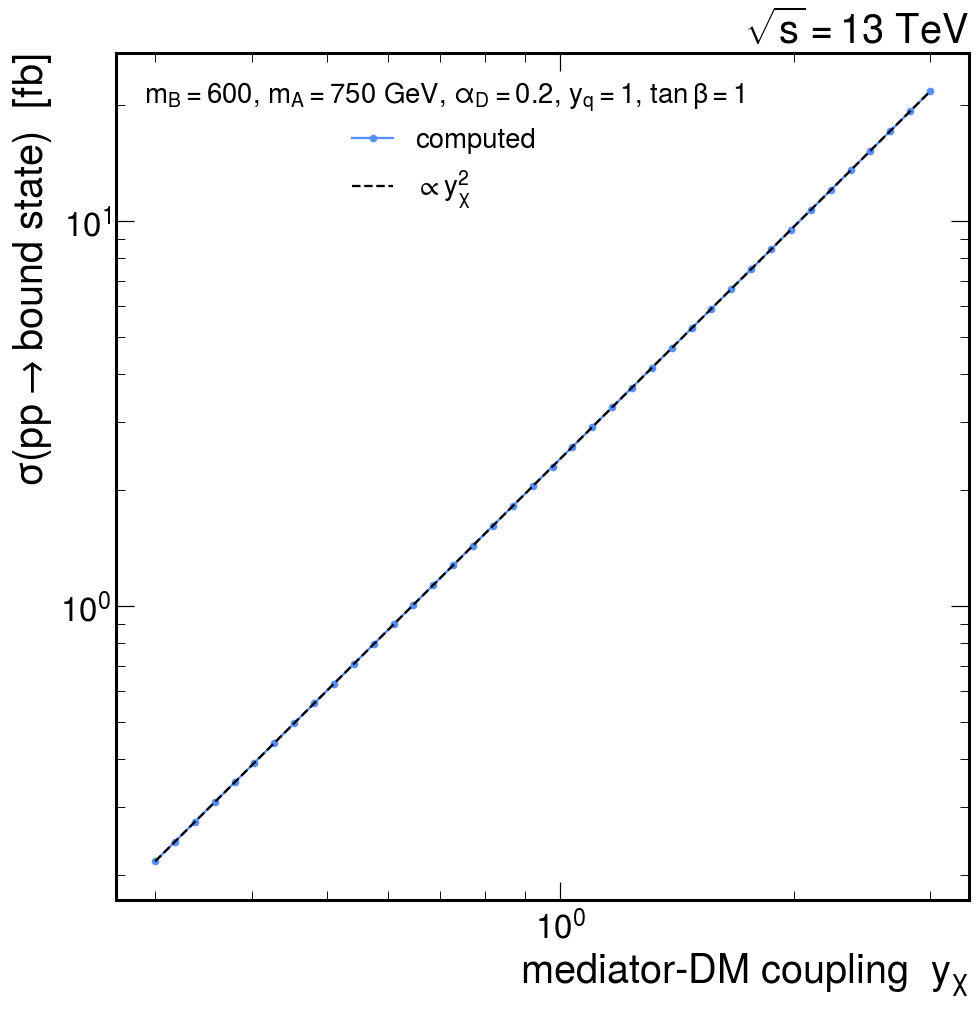

In [11]:
ychi = np.geomspace(0.3, 3, 40)
base = dict(mDM=px.mdm_from_mb(600, 0.2), mA=750, tanb=1, alphaD=0.2, yq=1, ychi=1)
sig = px.scan_param(pdf, "ychi", ychi, base)

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(ychi, sig, "C0o-", ms=4, lw=1.5, label="computed")
ax.plot(ychi, sig[0] * (ychi / ychi[0]) ** 2, "k--", lw=1.5, label=r"$\propto y_\chi^2$")
ax.set_xscale("log"); ax.set_yscale("log"); log_minor(ax); log_minor(ax, "x")
ax.set_xlabel(r"mediator-DM coupling  $y_\chi$")
ax.set_ylabel(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
leg(ax, title=r"$m_B=600$, $m_A=750$ GeV, $\alpha_D=0.2$, $y_q=1$, $\tan\beta=1$")
sqrt_s(ax)
plt.show()

### $y_q$ — the quark coupling (a surprise)

$y_q$ is more subtle because it shows up **twice**: in the production vertex ($\propto y_q^2$, more coupling means more signal) and in the mediator width $\Gamma_A\propto y_q^2$, which sets the resonance denominator. The two effects fight each other:

- **Off resonance**, the width doesn't matter and $\sigma\propto y_q^2$ — more coupling, more signal, as you'd expect.
- **On resonance**, the width dominates the denominator ($\propto y_q^4$), so $\sigma\propto1/y_q^2$ — **more quark coupling actually lowers the peak rate**, because it broadens the mediator faster than it feeds production.

The two opposite slopes ($+2$ and $-2$ on log–log) are shown below.

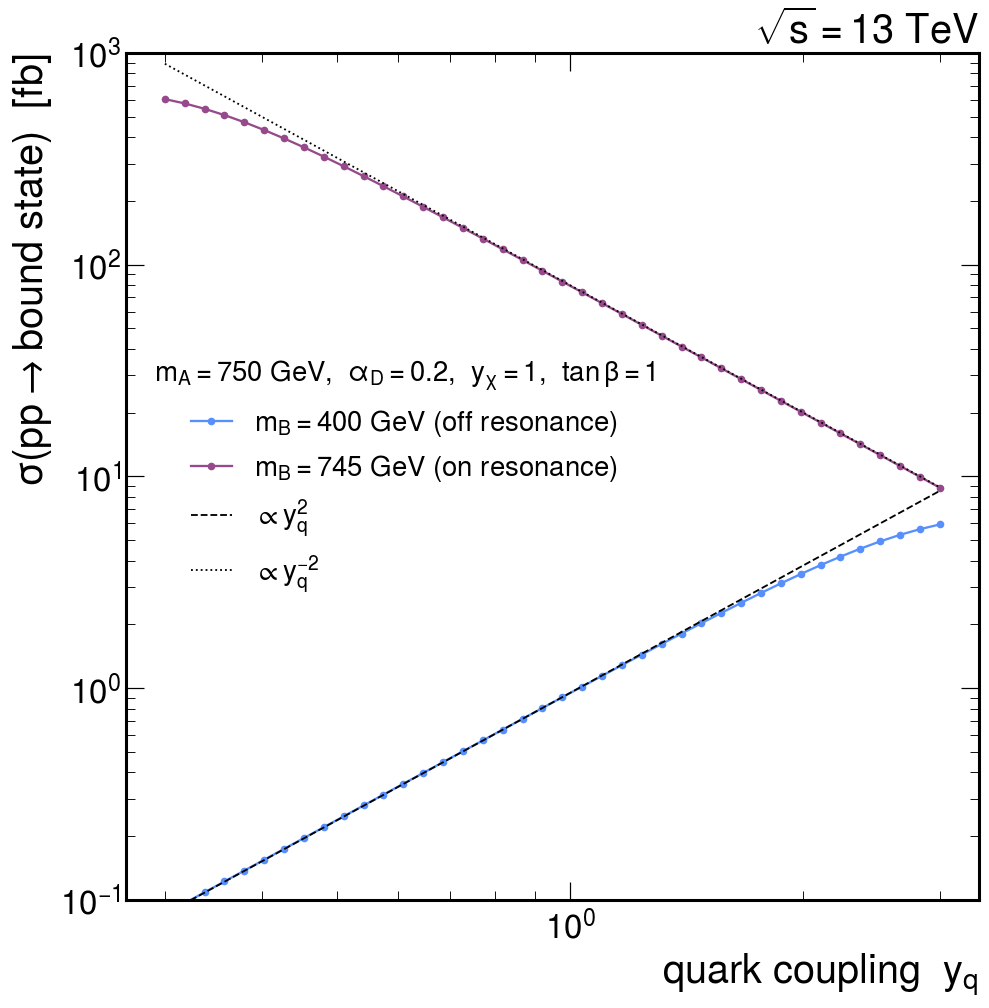

In [12]:
yq = np.geomspace(0.3, 3, 40)
fig, ax = plt.subplots(figsize=(10, 10))
for mB, tag, c in [(400, "off resonance", "C0"), (745, "on resonance", "C3")]:
    base = dict(mDM=px.mdm_from_mb(mB, 0.2), mA=750, tanb=1, alphaD=0.2, yq=1, ychi=1)
    sig = px.scan_param(pdf, "yq", yq, base)
    ax.plot(yq, sig, c + "o-", ms=4, lw=1.5, label=fr"$m_B={mB}$ GeV ({tag})")
ax.plot(yq, 0.95 * yq ** 2, "k--", lw=1.2, label=r"$\propto y_q^{2}$")
ax.plot(yq, 80 * yq ** -2, "k:", lw=1.2, label=r"$\propto y_q^{-2}$")
ax.set_xscale("log"); ax.set_yscale("log"); log_minor(ax); log_minor(ax, "x")
ax.set_xlabel(r"quark coupling  $y_q$")
ax.set_ylabel(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
ax.set_ylim(1e-1, 1e3)
leg(ax, title=r"$m_A=750$ GeV,  $\alpha_D=0.2$,  $y_\chi=1$,  $\tan\beta=1$")
sqrt_s(ax)
plt.show()

### $\tan\beta$ — the up/down coupling balance

$\tan\beta$ shifts weight between the top and bottom quarks: the down-type (bottom) coupling grows as $y_q\tan\beta$ and the up-type (top) as $y_q/\tan\beta$. Its effect on the rate depends on where you sit relative to the resonance, and the two regimes pull in opposite directions:

- **On resonance** ($m_B\approx m_A$), the rate **rises with $\tan\beta$** — by more than an order of magnitude across the range below. The bottom-quark coupling grows as $\tan\beta$ and increasingly feeds production (both the $b\bar b$ channel and the bottom-quark loop), and that outpaces the broadening of the mediator.
- **Off resonance**, the rate is **largest at small $\tan\beta$**, where the top-loop gluon-fusion channel is most active; it dips around $\tan\beta\sim4$, where the top and bottom contributions trade off, then recovers at large $\tan\beta$.

So $\tan\beta=1$ is not the maximum of the rate — it is simply the reference point where the up- and down-type couplings are equal (the universal-coupling case of Ref. [1]).

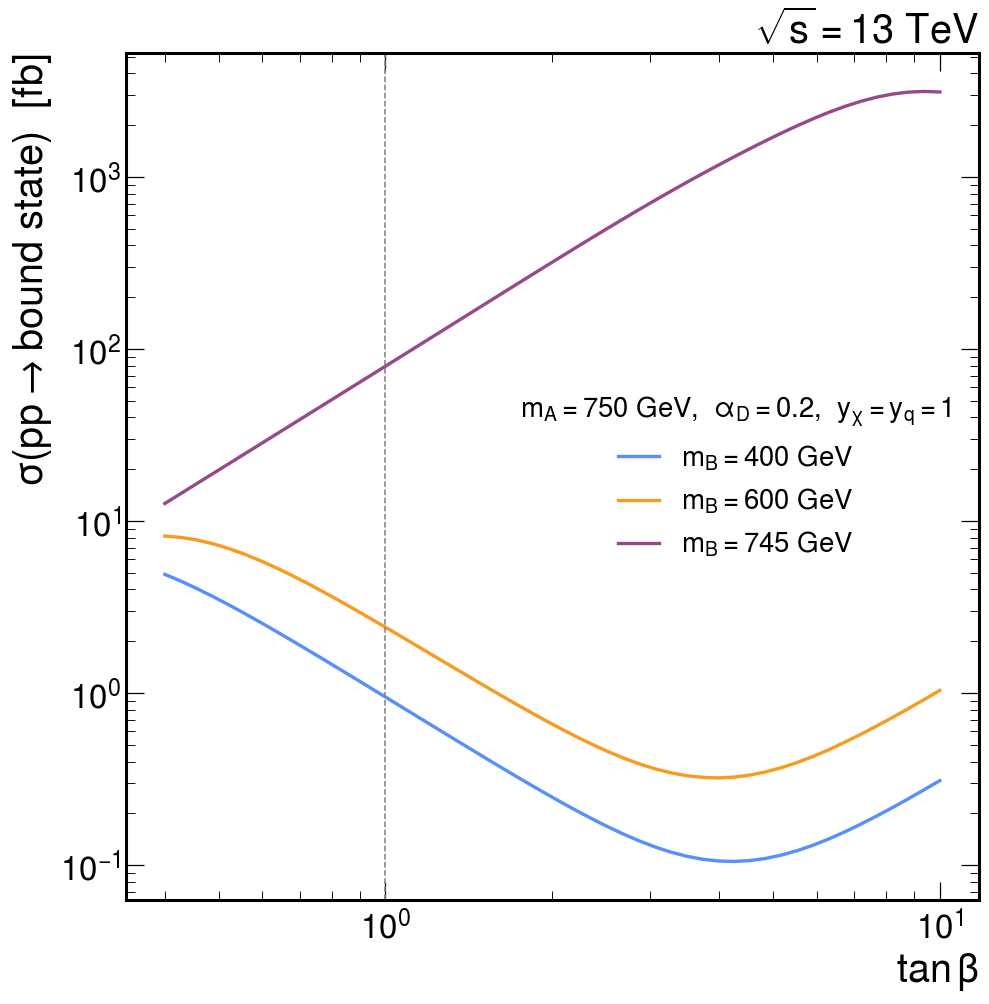

In [13]:
tanb = np.geomspace(0.4, 10, 50)
fig, ax = plt.subplots(figsize=(10, 10))
for mB, c in [(400, "C0"), (600, "C1"), (745, "C3")]:
    base = dict(mDM=px.mdm_from_mb(mB, 0.2), mA=750, tanb=1, alphaD=0.2, yq=1, ychi=1)
    sig = px.scan_param(pdf, "tanb", tanb, base)
    ax.plot(tanb, sig, c + "-", lw=2.2, label=fr"$m_B={mB}$ GeV")
ax.axvline(1, color="grey", ls="--", lw=1)
ax.set_xscale("log"); ax.set_yscale("log"); log_minor(ax); log_minor(ax, "x")
ax.set_xlabel(r"$\tan\beta$")
ax.set_ylabel(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
leg(ax, title=r"$m_A=750$ GeV,  $\alpha_D=0.2$,  $y_\chi=y_q=1$")
sqrt_s(ax)
plt.show()

### The $(m_B,\,\tan\beta)$ plane

Mass and $\tan\beta$ together: the rate concentrates along the resonance ridge $m_B\approx m_A=750$ GeV, and along that ridge it grows toward large $\tan\beta$ (the brightest part of the ridge is at the top of the plot) — consistent with the on-resonance curve above.

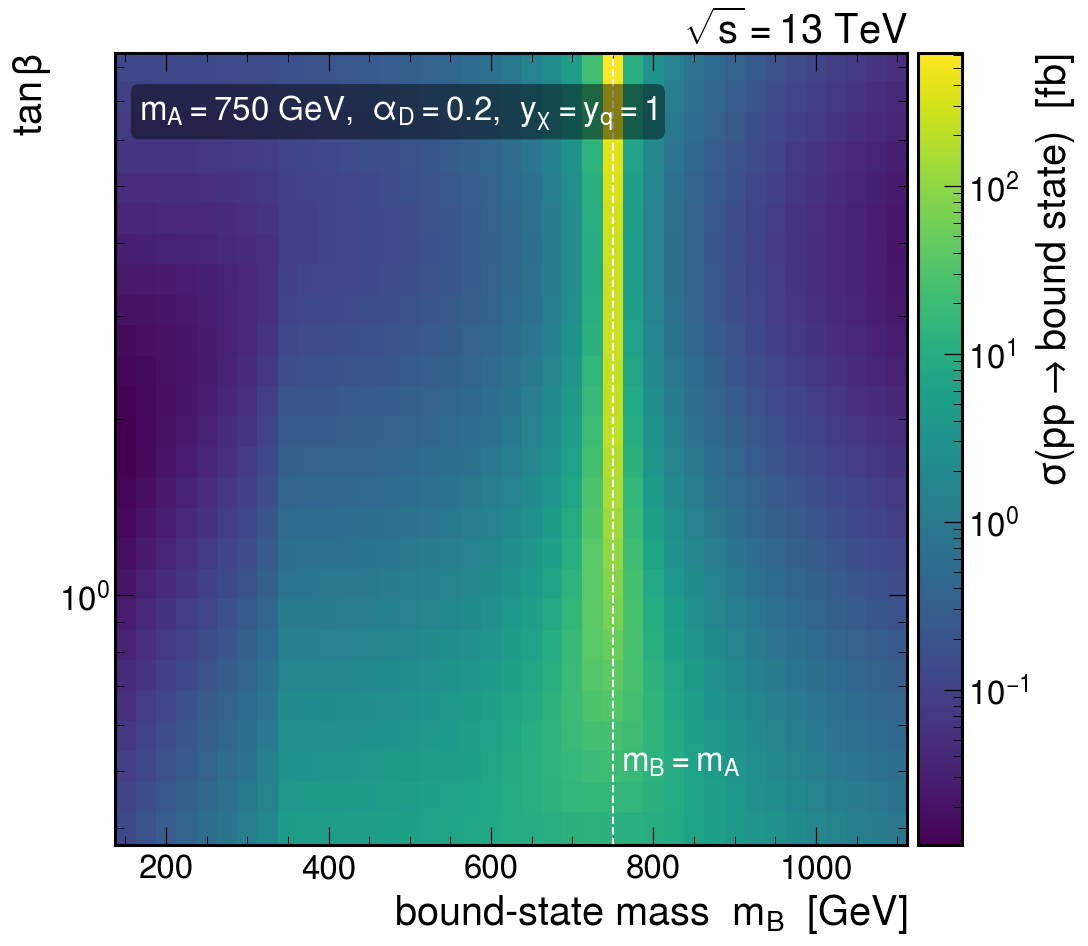

In [14]:
mB = np.arange(150, 1101, 25.0)
tanb = np.geomspace(0.4, 8, 26)
Z = np.array([px.scan_mB(pdf, mB, mA=750, tanb=tb, alphaD=0.2, yq=1, ychi=1)[2] for tb in tanb])

fig, ax = plt.subplots(figsize=(10, 10))
pcm = ax.pcolormesh(mB, tanb, Z, shading="auto", cmap="viridis",
                    norm=LogNorm(vmin=max(Z.min(), 1e-2), vmax=Z.max()))
ax.axvline(750, color="w", ls="--", lw=1.3)
ax.text(760, 0.5, r"$m_B=m_A$", color="w", fontsize="small")
ax.set_yscale("log"); log_minor(ax)
ax.set_xlabel(r"bound-state mass  $m_B$  [GeV]")
ax.set_ylabel(r"$\tan\beta$")
cax = hep.utils.make_square_add_cbar(ax, pad=0.1)
cb = fig.colorbar(pcm, cax=cax)
cb.set_label(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
ax.text(0.03, 0.95, r"$m_A=750$ GeV,  $\alpha_D=0.2$,  $y_\chi=y_q=1$",
        transform=ax.transAxes, va="top", color="white", fontsize="small",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="black", alpha=0.45, edgecolor="none"))
sqrt_s(ax)
plt.show()

## Summary table

Total cross section [fb] on a coarse $(m_B, m_A)$ grid for the benchmark couplings $\alpha_D=0.2$,
$y_\chi=y_q=1$, $\tan\beta=1$.

In [15]:
rows = []
for mA in [550, 650, 750, 850, 950, 1050]:
    for mB in [200, 400, 600, 800, 1000]:
        mDM = px.mdm_from_mb(mB, 0.2)
        rows.append({"m_A [GeV]": mA, "m_B [GeV]": mB,
                     "sigma [fb]": px.total_xsec(pdf, mDM, mA, 1, 0.2, 1, 1)})
table = (pd.DataFrame(rows)
         .pivot(index="m_A [GeV]", columns="m_B [GeV]", values="sigma [fb]")
         .round(4))
table

m_B [GeV],200,400,600,800,1000
m_A [GeV],,,,,
550,0.1982,7.6425,27.7080,0.8968,0.2087
650,0.0932,2.2359,24.8925,1.7041,0.2454
750,0.0499,0.9480,2.4127,8.8117,0.3416
850,0.0292,0.4846,0.7485,8.5106,0.6615
950,0.0183,0.2778,0.3331,0.9164,3.2141
1050,0.0121,0.1723,0.1774,0.2945,3.2597


# Part VI — Validation against the original calculation

To show that this Python port reproduces the original Mathematica calculation, we ship a file `mathematica_reference.json` with values computed directly in the Wolfram kernel from the original notebook: the parton distributions $xf(x,Q)$ and the total cross section $\sigma(m_B)$. The plots below overlay the Python results (curves) on those reference values (open circles), with the relative difference underneath. The two implementations are independent — a from-scratch NumPy rewrite of both the PDF interpolation and the cross-section formulas — so the agreement is a genuine cross-check.

In [16]:
ref = json.load(open("mathematica_reference.json"))
print("Reference loaded from the Wolfram kernel:")
print(f"  PDF samples : flavours {list(ref['pdf'])} at Q = {ref['meta']['Q_pdf']:.0f} GeV"
      f"  ({len(ref['pdf']['0']['x'])} x-points each)")
print(f"  sigma scans : m_A = {list(ref['sigma'])} GeV"
      f"  ({len(ref['sigma']['750']['mB'])} m_B-points each)")
print(f"  couplings   : alpha_D={ref['meta']['alphaD']}, y_chi={ref['meta']['ychi']}, "
      f"y_q={ref['meta']['yq']}, tan(beta)={ref['meta']['tanb']}")

Reference loaded from the Wolfram kernel:
  PDF samples : flavours ['0', '1', '2', '5'] at Q = 360 GeV  (27 x-points each)
  sigma scans : m_A = ['750', '950'] GeV  (19 m_B-points each)
  couplings   : alpha_D=0.2, y_chi=1, y_q=1, tan(beta)=1


## Parton distributions

The NumPy port of the MSTW2008 PDF interpolation compared with the Wolfram kernel, for the gluon, down, up, and bottom distributions at $Q=360$ GeV. The relative difference (lower panel) sits at $10^{-13}$–$10^{-15}$ — **machine precision**.

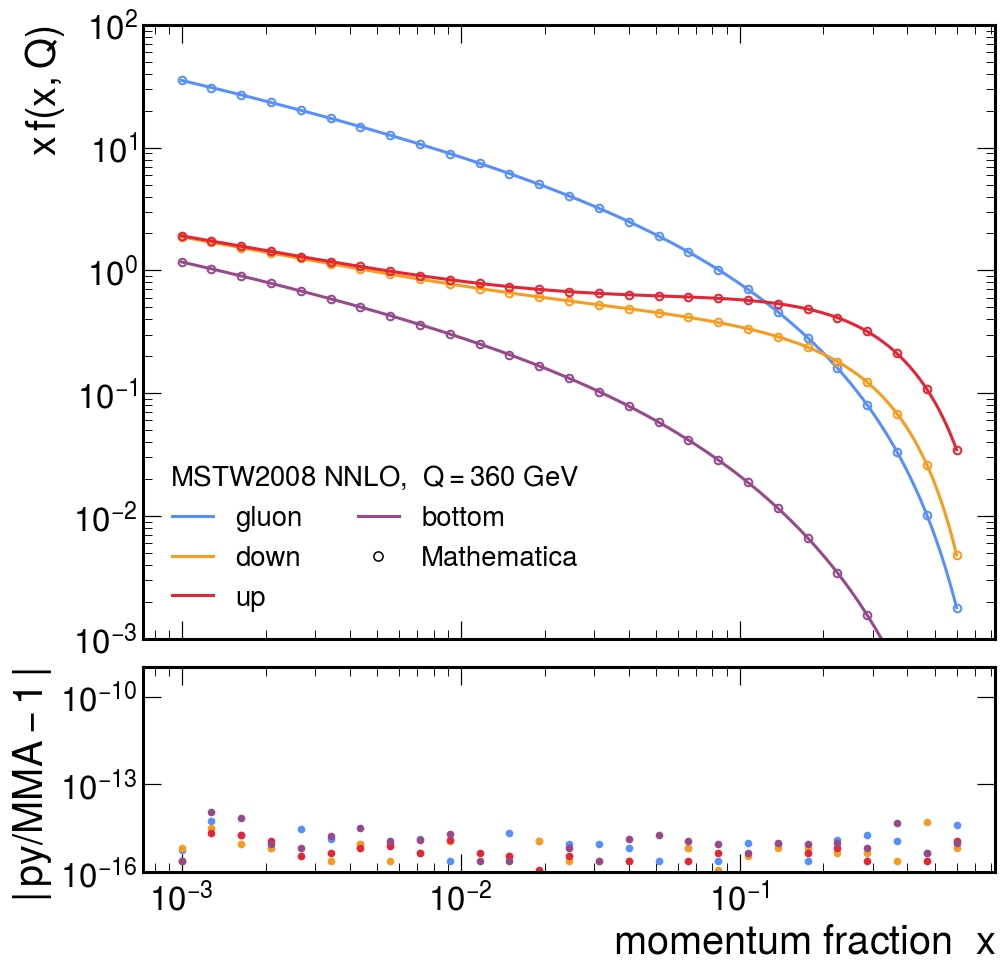

In [17]:
Q = ref["meta"]["Q_pdf"]
flav = {"0": ("gluon", "C0"), "1": ("down", "C1"), "2": ("up", "C2"), "5": ("bottom", "C3")}

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.07)
ax = fig.add_subplot(gs[0]); axr = fig.add_subplot(gs[1], sharex=ax)
xs = np.geomspace(1e-3, 0.6, 300)
for f, (name, c) in flav.items():
    ax.plot(xs, [pdf.xf(x, Q, int(f)) for x in xs], c + "-", lw=2, label=f"{name}")
    xm = np.array(ref["pdf"][f]["x"]); ym = np.array(ref["pdf"][f]["xf"])
    ax.plot(xm, ym, c + "o", ms=5, mfc="none", mew=1.3)
    yp = np.array([pdf.xf(x, Q, int(f)) for x in xm])
    axr.plot(xm, np.abs(yp / ym - 1) + 1e-17, c + "o", ms=4)
ax.plot([], [], "ko", mfc="none", label="Mathematica")
ax.set_xscale("log"); ax.set_yscale("log"); log_minor(ax)
ax.set_ylabel(r"$x\,f(x,Q)$")
ax.set_ylim(1e-3, 1e2)
leg(ax, title=fr"MSTW2008 NNLO,  $Q={Q:.0f}$ GeV", ncol=2)
ax.tick_params(labelbottom=False)
axr.set_xscale("log"); axr.set_yscale("log")
axr.set_ylim(1e-16, 1e-9)
axr.set_xlabel(r"momentum fraction  $x$")
axr.set_ylabel(r"$|\,\mathrm{py}/\mathrm{MMA}-1\,|$")
plt.show()

## Total cross section

The full cross-section chain (mixing, loops, parton-luminosity integral, K-factors) compared with the Wolfram kernel, for $m_A=750$ and $950$ GeV. The agreement is at the $10^{-7}$ level — that residual is just the difference between the numerical integration here (Gauss–Legendre) and Mathematica's adaptive integration, not a difference in the physics.

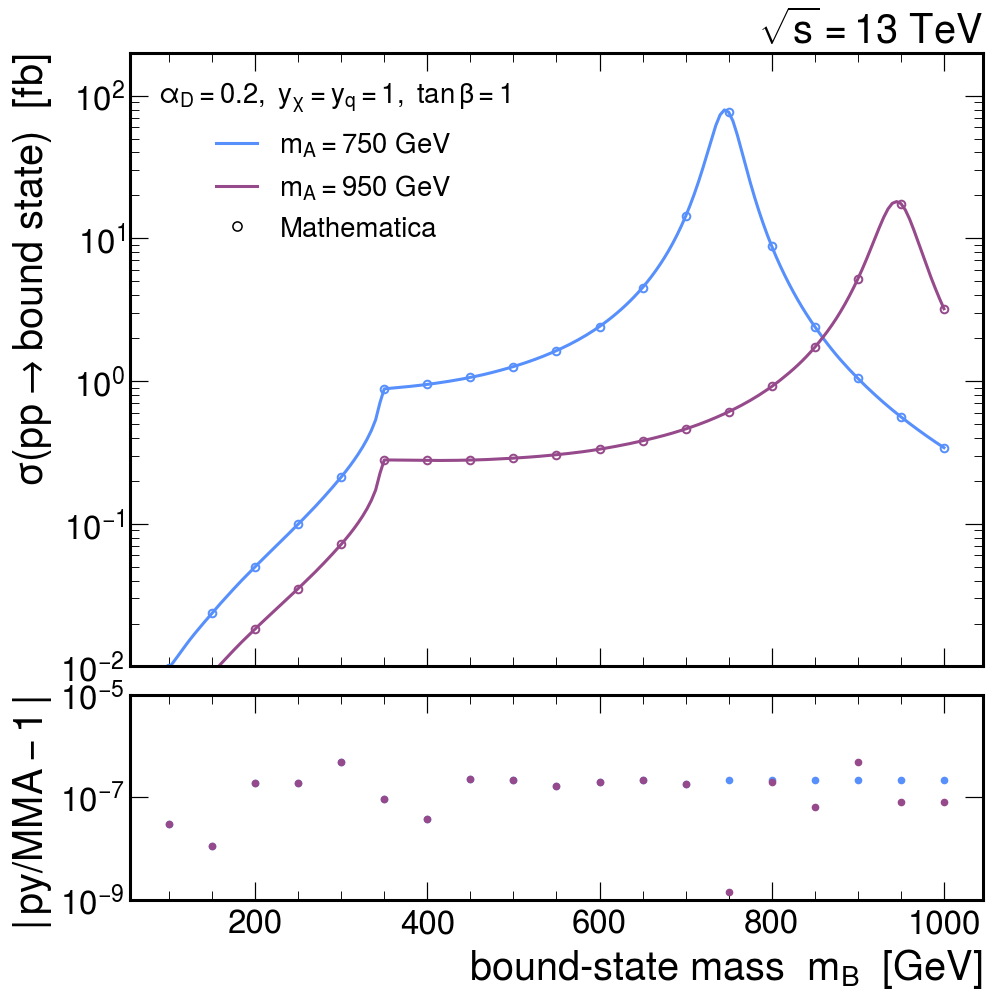

In [18]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.07)
ax = fig.add_subplot(gs[0]); axr = fig.add_subplot(gs[1], sharex=ax)
mBs = np.arange(100, 1001, 5.0)
for mA, c in [("750", "C0"), ("950", "C3")]:
    _, _, tot = px.scan_mB(pdf, mBs, mA=int(mA), tanb=1, alphaD=0.2, yq=1, ychi=1)
    ax.plot(mBs, tot, c + "-", lw=2, label=fr"$m_A={mA}$ GeV")
    xm = np.array(ref["sigma"][mA]["mB"]); ym = np.array(ref["sigma"][mA]["sigma"])
    ax.plot(xm, ym, c + "o", ms=5, mfc="none", mew=1.3)
    yp = np.array([px.total_xsec(pdf, px.mdm_from_mb(m, 0.2), int(mA), 1, 0.2, 1, 1) for m in xm])
    axr.plot(xm, np.abs(yp / ym - 1) + 1e-12, c + "o", ms=4)
ax.plot([], [], "ko", mfc="none", label="Mathematica")
ax.set_yscale("log"); log_minor(ax)
ax.set_ylabel(r"$\sigma(pp \to \mathrm{bound\ state})$  [fb]")
ax.set_ylim(1e-2, 2e2)
leg(ax, title=r"$\alpha_D=0.2,\ y_\chi=y_q=1,\ \tan\beta=1$")
ax.tick_params(labelbottom=False)
axr.set_yscale("log"); axr.set_ylim(1e-9, 1e-5)
axr.set_xlabel(r"bound-state mass  $m_B$  [GeV]")
axr.set_ylabel(r"$|\,\mathrm{py}/\mathrm{MMA}-1\,|$")
sqrt_s(ax)
plt.show()

**Summary.** Two independent implementations — the original Mathematica notebook and this NumPy port — agree to machine precision on the parton distributions and to $\sim10^{-7}$ on the full cross section, across the whole mass range, with no tuned constants. As noted in Part IV, the one approximation carried over from the original is the unit conversion ($\hbar c\approx2\times10^{-14}$ cm GeV, $\approx2.7\%$ high), and the calculation uses a single PDF set with fixed K-factors, so it has no PDF or scale uncertainty. The validation confirms that the code reproduces the original calculation, not that the absolute rate is precise.

# References

1. D. Abercrombie *et al.* (ATLAS/CMS Dark Matter Forum), *Dark Matter Benchmark Models for Early LHC
   Run-2 Searches: Report of the ATLAS/CMS Dark Matter Forum*, **arXiv:1507.00966** — pseudoscalar
   simplified model (Sec. 2.2, Eq. 2.7), $\tan\beta$ benchmark (Sec. 3.1.3).
2. T. Ahmed, M. Bonvini, M. C. Kumar, P. Mathews, N. Rana, V. Ravindran, L. Rottoli, *Pseudo-scalar
   Higgs boson production at N$^3$LO$_A$ + N$^3$LL$'$*, Eur. Phys. J. C **76** (2016) 663,
   **arXiv:1606.00837** — gluon-fusion K-factor $K_{gg}$.
3. R. V. Harlander, W. B. Kilgore, *Higgs boson production in bottom quark fusion at NNLO*, Phys.
   Rev. D **68** (2003) 013001, **arXiv:hep-ph/0304035** — heavy-quark ($b\bar b$) fusion K-factor
   $K_{q\bar q}$; scalar $=$ pseudoscalar to all orders by chiral symmetry.
4. Y. Tsai, L.-T. Wang, Y. Zhao, *Dark Matter Annihilation Decay at the LHC*, Phys. Rev. D **93**
   (2016) 035024, **arXiv:1511.07433** — dark-sector bound-state production: wavefunction at origin
   $|\psi(0)|^2=\alpha^3 m^3/(8\pi)$, the $\zeta(3)$ $nS$-tower sum, and the $q\bar q$ cross section.
5. G. Elor, H. Liu, T. R. Slatyer, Y. Soreq, *Complementarity for Dark Sector Bound States*, Phys.
   Rev. D **98** (2018) 036015, **arXiv:1801.07723** — the $2\times2$ complex mass-mixing matrix and
   Breit–Wigner mixing propagator between a mediator and a bound state.
6. A. D. Martin, W. J. Stirling, R. S. Thorne, G. Watt, *Parton distributions for the LHC*, Eur.
   Phys. J. C **63** (2009) 189, **arXiv:0901.0002** — MSTW2008 PDFs (NNLO central set used here).